# Bar Plot

In [21]:
#Load and sanity check
import numpy as np, pandas as pd
from pathlib import Path

RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
runs = pd.read_csv(RUN_LOG)

assert not runs.empty, "RUN_LOG is empty. Collect selections first."
need = {"selection","rep","p_med","p_high","p_int","n_sel"}
missing = need - set(runs.columns)
assert not missing, f"RUN_LOG missing columns: {missing}"

# summary print
print(f"Selections in log: {runs['selection'].nunique()} samples, {len(runs)} total rows")
display(runs.groupby("selection")["rep"].nunique().rename("n_reps").reset_index())


Selections in log: 5 samples, 15 total rows


,selection,n_reps
0,CyPSCA_1_1,3
1,CyPSCA_1_2,3
2,NoTx_2_2,3
3,RTCyPSCA_1_4,3
4,RTCyPSCA_2_4,3


In [22]:
# Aggregate mean ± SEM per sample (selection)
def sem(x):
    x = np.asarray(x, float)
    return np.nan if len(x) <= 1 else x.std(ddof=1)/np.sqrt(len(x))

agg = (runs.groupby("selection", as_index=False)
           .agg(n_reps=("rep","nunique"),
                p_med_mean=("p_med","mean"),  p_med_sem=("p_med",sem),
                p_high_mean=("p_high","mean"),p_high_sem=("p_high",sem),
                p_int_mean=("p_int","mean"),  p_int_sem=("p_int",sem),
                n_sel_total=("n_sel","sum")))

print("Per-sample replicate summary (mean ± SEM):")
display(agg)


Per-sample replicate summary (mean ± SEM):


,selection,n_reps,p_med_mean,p_med_sem,p_high_mean,p_high_sem,p_int_mean,p_int_sem,n_sel_total
0,CyPSCA_1_1,3,0.120863,0.002419,0.029050,0.004843,0.549993,0.000034,5711
1,CyPSCA_1_2,3,0.131935,0.009173,0.054018,0.011189,0.549996,0.000059,8351
2,NoTx_2_2,3,0.069382,0.005042,0.007162,0.002785,0.550062,0.000056,7590
3,RTCyPSCA_1_4,3,0.094037,0.006499,0.024038,0.001836,0.549951,0.000070,3664
4,RTCyPSCA_2_4,3,0.130418,0.007237,0.064975,0.012225,0.550091,0.000037,8315


Saved nothing yet — run the next cell to export.


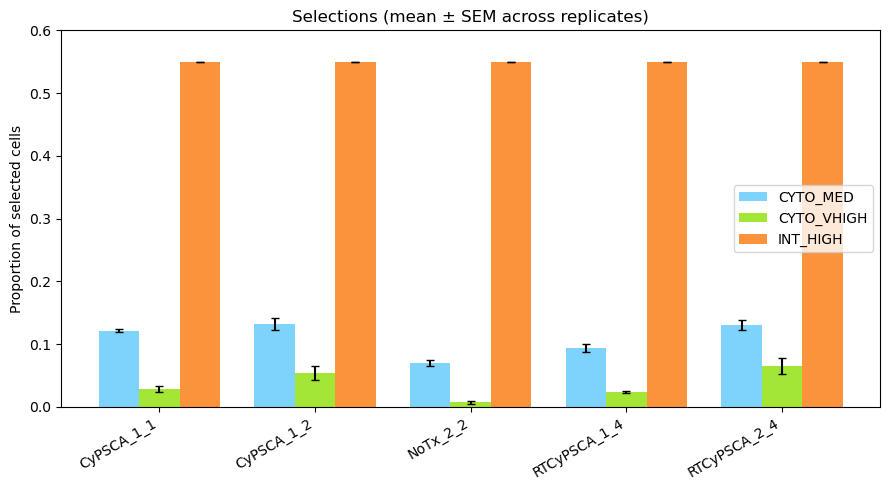

In [23]:
#Plotting
import matplotlib.pyplot as plt
import numpy as np

COL_MED  = "#7dd3fc"
COL_HIGH = "#a3e635"
COL_INT  = "#fb923c"

labels = agg["selection"].tolist()
x = np.arange(len(labels))
width = 0.26

fig, ax = plt.subplots(figsize=(max(8, 1.0*len(labels)+4), 5))
ax.bar(x - width, agg["p_med_mean"],  width, yerr=agg["p_med_sem"],  capsize=3, color=COL_MED,  label="CYTO_MED")
ax.bar(x,         agg["p_high_mean"], width, yerr=agg["p_high_sem"], capsize=3, color=COL_HIGH, label="CYTO_VHIGH")
ax.bar(x + width, agg["p_int_mean"],  width, yerr=agg["p_int_sem"],  capsize=3, color=COL_INT,  label="INT_HIGH")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Proportion of selected cells")
ax.set_title("Selections (mean ± SEM across replicates)")
ax.set_ylim(0, max(0.02, float( (agg[["p_med_mean","p_high_mean","p_int_mean"]].to_numpy().max() + 0.05) )))
ax.legend(frameon=True)
plt.tight_layout()

# brief summary at end of cell
print("Saved nothing yet — run the next cell to export.")


In [24]:
# # Saving
# from pathlib import Path
# OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# STEM = "Selections__mean±SEM"
# for ext in ["png", "pdf"]:
#     path = OUT_DIR / f"{STEM}.{ext}"
#     fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.02)
#     print("Saved:", path)


In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# --- output location ---
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- colors ---
COL_MED  = "#7dd3fc"
COL_HIGH = "#a3e635"
COL_INT  = "#fb923c"

labels = agg["selection"].tolist()
x = np.arange(len(labels))
width = 0.26

fig, ax = plt.subplots(figsize=(max(8, 1.0*len(labels)+4), 5))
ax.bar(x - width, agg["p_med_mean"],  width, yerr=agg["p_med_sem"],  capsize=3, color=COL_MED,  label="CYTO_MED")
ax.bar(x,         agg["p_high_mean"], width, yerr=agg["p_high_sem"], capsize=3, color=COL_HIGH, label="CYTO_VHIGH")
ax.bar(x + width, agg["p_int_mean"],  width, yerr=agg["p_int_sem"],  capsize=3, color=COL_INT,  label="INT_HIGH")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Proportion of selected cells")
ax.set_title("Selections (mean ± SEM across replicates)")

ylim_auto = float(agg[["p_med_mean","p_high_mean","p_int_mean"]].to_numpy().max()) + 0.05
ax.set_ylim(0, max(0.02, ylim_auto))
ax.legend(frameon=True)
plt.tight_layout()

STEM = "Selections__mean±SEM__ALL"
fig.savefig(OUT_DIR / f"{STEM}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
fig.savefig(OUT_DIR / f"{STEM}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

print("Saved:", OUT_DIR / f"{STEM}.png")
print("Saved:", OUT_DIR / f"{STEM}.pdf")


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__ALL.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__ALL.pdf


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# map: column -> (pretty label, color)
CATS = {
    "p_med":  ("CYTO_MED",  "#7dd3fc"),
    "p_high": ("CYTO_VHIGH","#a3e635"),
    "p_int":  ("INT_HIGH",  "#fb923c"),
}

labels = agg["selection"].tolist()
x = np.arange(len(labels))

# Optional fixed y-limits per category (uncomment to enforce)
# YLIMS = {"p_med": 0.40, "p_high": 0.10, "p_int": 0.40}
YLIMS = {}

for key, (pretty, color) in CATS.items():
    y    = agg[f"{key}_mean"].to_numpy()
    yerr = agg[f"{key}_sem"].to_numpy()

    fig, ax = plt.subplots(figsize=(max(6.5, 0.9*len(labels)+3), 4.5))
    ax.bar(x, y, 0.6, yerr=yerr, capsize=3, color=color)

    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Proportion of selected cells")
    ax.set_title(f"{pretty} (mean ± SEM across replicates)")

    if key in YLIMS:
        ax.set_ylim(0, YLIMS[key])
    else:
        ax.set_ylim(0, max(0.02, float(y.max()) + 0.05))

    plt.tight_layout()

    STEM = f"Selections__mean±SEM__{pretty}"
    fig.savefig(OUT_DIR / f"{STEM}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(OUT_DIR / f"{STEM}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    print("Saved:", OUT_DIR / f"{STEM}.png")
    print("Saved:", OUT_DIR / f"{STEM}.pdf")


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_MED.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_MED.pdf
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_VHIGH.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_VHIGH.pdf
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__INT_HIGH.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__INT_HIGH.pdf


In [16]:
# --- Stand-alone CYTO_VHIGH barplot (subset + renamed labels + fixed order) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---------- inputs / outputs ----------
RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
STEM    = "Cytotoxic cell proportions"

# ---------- load ----------
runs = pd.read_csv(RUN_LOG)
need = {"selection","rep","p_med","p_high","p_int","n_sel"}
missing = need - set(runs.columns)
assert not runs.empty and not missing, f"Log empty or missing cols: {missing}"

# ---------- subset samples ----------
sample_focus = ["RTCyPSCA_2_4", "CyPSCA_1_1", "NoTx_2_2", "RTCyPSCA_1_4"]
runs = runs[runs["selection"].isin(sample_focus)].copy()

# map sample -> pretty label
label_map = {
    "CyPSCA_1_1": "CyPSCA",
    "NoTx_2_2": "No Treatment",
    "RTCyPSCA_1_4": "RTCyPSCA (RT)",
    "RTCyPSCA_2_4": "RTCyPSCA (No RT)",
}

# enforce desired plotting order
ordered_labels = ["No Treatment", "CyPSCA", "RTCyPSCA (RT)", "RTCyPSCA (No RT)"]

# ---------- aggregate (mean ± SEM per selection) ----------
def sem(x):
    x = np.asarray(x, float)
    return np.nan if len(x) <= 1 else x.std(ddof=1) / np.sqrt(len(x))

agg = (runs.groupby("selection", as_index=False)
           .agg(n_reps=("rep","nunique"),
                p_high_mean=("p_high","mean"),
                p_high_sem =("p_high",sem)))

# add pretty labels + reorder
agg["pretty"] = agg["selection"].map(label_map)
agg = agg.set_index("pretty").loc[ordered_labels].reset_index()

labels = agg["pretty"].tolist()
x = np.arange(len(labels))
y = agg["p_high_mean"].to_numpy()
yerr = agg["p_high_sem"].to_numpy()

# ---------- plot ----------
COL_HIGH = "#a3e635"
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, y, 0.6, yerr=yerr, capsize=3, color=COL_HIGH)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_xlabel("Condition")
ax.set_title("Cytotoxic cell percentages")

# y-axis in percent
ymax_default = 0.08
ymax = max(ymax_default, float(np.nanmax(y + np.nan_to_num(yerr, nan=0))) + 0.01)
step = 0.02
ymax = step * np.ceil(ymax / step)
ax.set_ylim(0, ymax)
ticks = np.arange(0, ymax + 1e-9, step)
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(100*t)}%" if (100*t).is_integer() else f"{100*t:.1f}%" for t in ticks])
ax.set_ylabel("Percentage of cells (%)")

plt.tight_layout()

# ---------- save ----------
png_path = OUT_DIR / f"{STEM}.png"
pdf_path = OUT_DIR / f"{STEM}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
fig.savefig(pdf_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

print("Saved:", png_path)
print("Saved:", pdf_path)
print("Plotted order:", " → ".join(labels))


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Cytotoxic cell proportions.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Cytotoxic cell proportions.pdf
Plotted order: No Treatment → CyPSCA → RTCyPSCA (RT) → RTCyPSCA (No RT)


# T-test

In [17]:
# --- Pairwise t-tests across selected conditions (CYTO_VHIGH) and save to Excel ---
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import ttest_ind
import itertools

# ---------- inputs ----------
RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- load ----------
runs = pd.read_csv(RUN_LOG)
need = {"selection","rep","p_high"}
missing = need - set(runs.columns)
assert not runs.empty and not missing, f"Log empty or missing cols: {missing}"

# ---------- subset ----------
sample_focus = ["RTCyPSCA_2_4", "CyPSCA_1_1", "NoTx_2_2", "RTCyPSCA_1_4"]
label_map = {
    "CyPSCA_1_1": "CyPSCA",
    "NoTx_2_2": "No Treatment",
    "RTCyPSCA_1_4": "RTCyPSCA (RT)",
    "RTCyPSCA_2_4": "RTCyPSCA (NoRT)",
}
runs = runs[runs["selection"].isin(sample_focus)].copy()
runs["condition"] = runs["selection"].map(label_map)

# ---------- pairwise t-tests ----------
results = []
for (c1, c2) in itertools.combinations(runs["condition"].unique(), 2):
    vals1 = runs.loc[runs["condition"] == c1, "p_high"].to_numpy()
    vals2 = runs.loc[runs["condition"] == c2, "p_high"].to_numpy()
    if len(vals1) > 1 and len(vals2) > 1:
        stat, pval = ttest_ind(vals1, vals2, equal_var=False, nan_policy="omit")
    else:
        stat, pval = np.nan, np.nan
    results.append({"Condition1": c1, "Condition2": c2,
                    "t_stat": stat, "p_value": pval})

ttest_df = pd.DataFrame(results)

# ---------- save ----------
excel_path = OUT_DIR / "CYTO_VHIGH_ttests.xlsx"
ttest_df.to_excel(excel_path, index=False)

print("Saved t-test results to:", excel_path)
display(ttest_df)


Saved t-test results to: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/CYTO_VHIGH_ttests.xlsx


,Condition1,Condition2,t_stat,p_value
0,CyPSCA,No Treatment,3.917692,0.026396
1,CyPSCA,RTCyPSCA (RT),0.967586,0.415445
2,CyPSCA,RTCyPSCA (NoRT),-2.731971,0.083661
3,No Treatment,RTCyPSCA (RT),-5.058713,0.010453
4,No Treatment,RTCyPSCA (NoRT),-4.610807,0.036344
5,RTCyPSCA (RT),RTCyPSCA (NoRT),-3.311356,0.075682


In [19]:
# --- One-sided t-test: RTCyPSCA (NoRT) > RTCyPSCA (RT) ---
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import ttest_ind

# ---------- inputs ----------
RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- load ----------
runs = pd.read_csv(RUN_LOG)
need = {"selection","rep","p_high"}
missing = need - set(runs.columns)
assert not runs.empty and not missing, f"Log empty or missing cols: {missing}"

# ---------- subset ----------
label_map = {
    "RTCyPSCA_1_4": "RTCyPSCA (RT)",
    "RTCyPSCA_2_4": "RTCyPSCA (NoRT)",
}
runs = runs[runs["selection"].isin(label_map.keys())].copy()
runs["condition"] = runs["selection"].map(label_map)

vals_NoRT = runs.loc[runs["condition"]=="RTCyPSCA (NoRT)", "p_high"].to_numpy()
vals_RT   = runs.loc[runs["condition"]=="RTCyPSCA (RT)",   "p_high"].to_numpy()

# ---------- one-sided Welch's t-test ----------
t_stat, pval_two_sided = ttest_ind(vals_NoRT, vals_RT, equal_var=False, nan_policy="omit")
pval_one_sided = pval_two_sided / 2 if t_stat > 0 else 1.0

# ---------- save results ----------
results = {
    "Condition1": ["RTCyPSCA (NoRT)"],
    "Condition2": ["RTCyPSCA (RT)"],
    "Mean1": [np.mean(vals_NoRT)],
    "Mean2": [np.mean(vals_RT)],
    "t_stat": [t_stat],
    "p_value_one_sided": [pval_one_sided],
}
df_out = pd.DataFrame(results)

excel_path = OUT_DIR / "OnceSided_ttest_NoRT_vs_RT.xlsx"
df_out.to_excel(excel_path, index=False)

print("Saved one-sided t-test results to:", excel_path)
display(df_out)


Saved one-sided t-test results to: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/OnceSided_ttest_NoRT_vs_RT.xlsx


,Condition1,Condition2,Mean1,Mean2,t_stat,p_value_one_sided
0,RTCyPSCA (NoRT),RTCyPSCA (RT),0.064975,0.024038,3.311356,0.037841


In [27]:
# --- One-sided t-tests: RTCyPSCA (NoRT) > all others ---
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import ttest_ind

# ---------- inputs ----------
RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- load ----------
runs = pd.read_csv(RUN_LOG)
need = {"selection","rep","p_high"}
missing = need - set(runs.columns)
assert not runs.empty and not missing, f"Log empty or missing cols: {missing}"

# ---------- subset ----------
sample_focus = ["RTCyPSCA_2_4", "CyPSCA_1_1", "NoTx_2_2", "RTCyPSCA_1_4"]
label_map = {
    "CyPSCA_1_1": "CyPSCA",
    "NoTx_2_2": "No Treatment",
    "RTCyPSCA_1_4": "RTCyPSCA (RT)",
    "RTCyPSCA_2_4": "RTCyPSCA (NoRT)",
}
runs = runs[runs["selection"].isin(sample_focus)].copy()
runs["condition"] = runs["selection"].map(label_map)

# ---------- one-sided tests: NoRT vs all others ----------
results = []
vals_NoRT = runs.loc[runs["condition"]=="RTCyPSCA (NoRT)", "p_high"].to_numpy()

for cond in runs["condition"].unique():
    if cond == "RTCyPSCA (NoRT)":
        continue
    vals_other = runs.loc[runs["condition"]==cond, "p_high"].to_numpy()
    if len(vals_NoRT) > 1 and len(vals_other) > 1:
        t_stat, pval_two_sided = ttest_ind(vals_NoRT, vals_other, equal_var=False, nan_policy="omit")
        pval_one_sided = pval_two_sided / 2 if t_stat > 0 else 1.0
    else:
        t_stat, pval_one_sided = np.nan, np.nan
    
    results.append({
        "Condition1": "RTCyPSCA (NoRT)",
        "Condition2": cond,
        "Mean1": np.mean(vals_NoRT),
        "Mean2": np.mean(vals_other),
        "t_stat": t_stat,
        "p_value_one_sided": pval_one_sided
    })

df_out = pd.DataFrame(results)

# ---------- save ----------
excel_path = OUT_DIR / "CYTO_VHIGH_ttests_NoRT_vs_all.xlsx"
df_out.to_excel(excel_path, index=False)

print("Saved one-sided t-test results to:", excel_path)
display(df_out)


Saved one-sided t-test results to: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/CYTO_VHIGH_ttests_NoRT_vs_all.xlsx


,Condition1,Condition2,Mean1,Mean2,t_stat,p_value_one_sided
0,RTCyPSCA (NoRT),CyPSCA,0.064975,0.029050,2.731971,0.041830
1,RTCyPSCA (NoRT),No Treatment,0.064975,0.007162,4.610807,0.018172
2,RTCyPSCA (NoRT),RTCyPSCA (RT),0.064975,0.024038,3.311356,0.037841
